**In this Notebook, I am getting familiar with the [modern dataset (Chen)](https://zenodo.org/records/7306199) (download the *.nc* file).**

This dataset is not a direct output from isotope-enabled GCMs. Instead, it has been generated through data fusion and bias correction techniques based on GCM outputs. In other words, post-processing methods were applied to the model outputs to bring the simulations closer to observational data. This dataset is 1870–2017 at a monthly scale.

First, we import useful libraries and read the netCTF4 file with xarray to get a Dataset object. 

In [1]:
import pandas as pd
import xarray as xr
from geostat_isoscapes_tools import geostat_utils as gutils
from geostat_isoscapes_tools import plot_utils as putils
import matplotlib.pyplot as plt 
import numpy as np
import plotly as px
import skgstat as skg
from tqdm import tqdm

from scipy.spatial.distance import pdist

import seaborn as sns

import geopandas as gpd
from shapely.geometry import Point
from mpl_toolkits.axes_grid1 import make_axes_locatable


sns.set_style('dark')
fn = '../data/modern/PrecipOxygenIso_mainlandCHINA_1870to2017_v2.nc'

In [2]:
with xr.open_dataset(filename_or_obj=fn, engine='netcdf4',decode_times=False) as file:
    d18Op = file.d18Op

# make the time dimension a datetime index, starting from 1870-01-01, with monthly frequence so that time 1 becomes 1870-01-31, etc.
time_index = pd.date_range(start='1870-01-31', periods=d18Op.sizes['time'], freq='ME')
d18Op = d18Op.assign_coords(time=time_index)
# transpose so that the order of the dims is lat/lon and not lon/lat (pb with plotting fct and flattening otherwise)
d18Op = d18Op.transpose('time','lat','lon')

### Basic plots

In [ ]:
# Plot with cartopy
da_sel = d18Op.sel(time='1968-12-31') #1775
fig,ax = putils.plot_isoscape_latlon_platecarree(da_sel,time='1968-12')
# # plt.savefig("../output/itrace_artifacts_example.png",dpi=400)
plt.show()

In [ ]:
# Mean across all lat/lon with std shown
global_std = d18Op.std(dim=("lat", "lon"))
plt.figure(figsize=(30,8))
global_mean = d18Op.mean(dim=("lat", "lon"))
global_mean.plot.line(x="time")
plt.fill_between(global_mean.time.values, 
                 (global_mean - global_std).values, 
                 (global_mean + global_std).values, 
                 color='b', alpha=0.1, label='±1 std dev')
plt.title('Time evolution of the d18Op value averaged accross all locations.')
plt.show()

# Mean across all lat/lon re-averaged by batch of 12 months
plt.figure(figsize=(30,8))

global_mean_12m = d18Op.resample(time='12ME').mean().mean(dim=("lat", "lon"))
global_std_12m = d18Op.resample(time='12ME').mean().std(dim=("lat", "lon"))
global_mean_12m.plot.line(x="time")
plt.fill_between(global_mean_12m.time.values, 
                 (global_mean_12m - global_std_12m).values, 
                 (global_mean_12m + global_std_12m).values, 
                 color='b', alpha=0.1, label='±1 std dev')
plt.title('Time evolution of the d18Op value averaged accross all locations and re-averaged by batch of 12 months.')
plt.show()

In [ ]:
# mean and variance accross time
mean_d18Op = d18Op.transpose('time','lat','lon').mean(dim="time")
std_d18Op = d18Op.transpose('time','lat','lon').std(dim="time")   

fig, ax = putils.plot_isoscape_latlon_platecarree(mean_d18Op, time='1870-2017', title="Average values of d18Op")
plt.show()

fig,ax=putils.plot_isoscape_latlon_platecarree(std_d18Op,time='1870-2017', title='Std values of d18Op')
plt.show()


High varibaility in NW region was explained by authors in the dataset's paper :

*"For NW, the variability of δ18Op simulations is also large. This is because, on the one hand, the sparse coverage of stations coupled with complex topography over northwest China cannot well represent the full range of precipitation isotope conditions. This can lead to biases in the distribution of observations. On the other hand, the arid northwest region is one of the most sensitive regions to climate change due to its fragile ecosystem, which affects sub-cloud evaporation and local moisture re-cycling, leading to the large uncertainty in isotope simulation between different iGCMs23,81."*

### Variogram for a given time point (month)

In [ ]:
time = '2006-11-30' 

#### Experimental Variogram (gstat, Euclidean distances) 

In [ ]:
# Prepare data
coords_proj, vals_s = gutils.get_projected_coords_and_vals(d18Op, time=time, epsg="EPSG:3857")
# Plot projected data
fig, ax = putils.plot_projected_data(coords_proj, vals_s, projection_str='Mercator')
plt.show()

# Compute Variogram
V = skg.Variogram(coords_proj, vals_s, n_lags=20, maxlag='median', model='spherical', use_nugget=True, normalize=False)

fig,ax = putils.plot_variogram_from_bins_and_gamma(V.bins,
                                                   V.experimental,
                                                   time,V.bin_count,
                                                   min_pairs=30,
                                                   plot_model=False,
                                                   model_name=V._model_name,
                                                   model_fct=V.fitted_model)

#### Experimental Variogram of the **residuals** after trend removal (gstat, Euclidean distances)

In [ ]:
coords, vals_s = gutils.get_projected_coords_and_vals(d18Op,time=time,epsg="EPSG:3857")

resid = gutils.detrend_data(coords,vals_s)

# quick check: variance reduction after detrend
print("Var(original) =", np.var(vals_s), " Var(residual) =", np.var(resid))

# sensible maxlag: e.g. half the maximum pairwise distance or 1/3
dmax = pdist(coords).max()
maxlag = dmax *0.6

# build variogram on residuals, with metric distances, no normalization
V = skg.Variogram(coords, resid,
                  n_lags=40,
                  maxlag=maxlag,
                  model='gaussian+spherical',
                  use_nugget=True,
                  normalize=False,
                  verbose=True)

fig, ax = putils.plot_variogram_from_bins_and_gamma(V.bins,
                                                    V.experimental,
                                                    time,
                                                    V.bin_count,
                                                    min_pairs=30,
                                                    plot_model=True,
                                                    model_name=V._model_name,
                                                    model_fct = V.fitted_model,
                                                    )

#### Experimental Variograms using geodesic distances

In [ ]:
da_slice = d18Op.sel(time=time) 

# Get lon, lat, and values (1D)
lon2d, lat2d = np.meshgrid(da_slice['lon'].values, da_slice['lat'].values)
values = da_slice.values
mask = ~np.isnan(values)
lons = lon2d[mask]
lats = lat2d[mask]
vals = values[mask]
lonlat = np.column_stack((lons, lats))

# remove linear trend 
X = np.column_stack((lons, lats))
residuals = gutils.detrend_data(X,vals)

# Compute distances (meters)
distances = gutils.geodesic_condensed_distances(lonlat)
print(f"Max pairwise distance: {distances.max()/1000:.1f} km")

# Compute semivariances
# pdist (to compute on each pair) with a custom lambda for squared difference (->computes squared diff of each pair)
semivars = pdist(residuals.reshape(-1, 1), lambda u, v: 0.5 * (u - v) ** 2)

# Bin distances into lag classes
n_bins = 40
maxlag = distances.max() * 0.65 
bins = np.linspace(0, maxlag, n_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Assign each distance to a bin
bin_idx = np.digitize(distances, bins) - 1

# Compute mean semivariance per bin
gamma = np.full(n_bins, np.nan)
counts = np.zeros(n_bins, dtype=int)

for k in range(n_bins):
    sel = bin_idx == k
    counts[k] = np.sum(sel)
    if counts[k] > 0:
        gamma[k] = np.mean(semivars[sel])

# Mask unreliable bins (few pairs)
min_pairs = 30  # threshold of minimum pairs per bin
reliable = counts >= min_pairs

fig, ax1 = plt.subplots(figsize=(9, 6))

# Plot semivariance
ax1.plot(bin_centers[reliable]/1000, gamma[reliable], 'o', color='blue', label='Empirical γ(h)')
ax1.set_xlabel('Lag distance (km)')
ax1.set_ylabel('Semivariance (δ$^{18}$O$_p$)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Overlay pair counts
ax2 = ax1.twinx()
ax2.bar(bin_centers/1000, counts, width=(bin_centers[1]-bin_centers[0])/1000,
        color='red', alpha=0.1, label='Pair counts')
ax2.set_ylabel('Number of pairs', color='red')
ax2.tick_params(axis='y', labelcolor='red')
plt.xlim(0, maxlag/1000)
plt.title('Empirical variogram of the residuals after trend removal (geodesic distances)')
plt.grid(True, alpha=0.4)
plt.show()

#### *drafts - variograms computations*

In [ ]:
coord_proj, vals_s = gutils.get_projected_coords_and_vals(d18Op, time=time, epsg="EPSG:3857")

centers, gamma, counts = gutils.variogram_gstools(coords_proj, vals_s, n_bins=40, maxlag=4000000)

# plot
fig, ax = putils.plot_variogram_from_bins_and_gamma(centers,gamma,time,counts,min_pairs=30)
plt.show()

In [ ]:
# prepare A (meshgrid) and B (to_dataframe) again
da_slice = d18Op.sel(time='1969-12-31')
lons = da_slice['lon'].values
lats = da_slice['lat'].values
lon_grid, lat_grid = np.meshgrid(lons, lats,indexing='ij')   # <- indexing='ij' to preserve order
coords = np.column_stack([lon_grid.ravel(order='C'), lat_grid.ravel(order='C')])
values = da_slice.values.ravel(order='C')
mask = ~np.isnan(values)
coords_A = coords[mask]
vals_A = values[mask]

df = d18Op.to_dataframe(name='d18Op').reset_index()
df = df[(df['time'].dt.year==1969) & (df['time'].dt.month==12) & (df['time'].dt.day==31)].dropna(subset=['d18Op']).copy()
coords_B = df[['lon','lat']].values
vals_B = df['d18Op'].values

print('counts A,B:', coords_A.shape[0], coords_B.shape[0])
print('da_slice.shape, coords grid shape:', da_slice.shape, lon_grid.shape)

# compare lon/lat pairs before projection
setA = set(map(tuple, np.round(coords_A, 6)))
setB = set(map(tuple, np.round(coords_B, 6)))
print('n only in A:', len(setA - setB))
print('n only in B:', len(setB - setA))
# show some examples
print('examples only in A (first 5):', list(setA - setB)[:5])
print('examples only in B (first 5):', list(setB - setA)[:5])

# check lon ranges / ordering
print('lons range (grid):', lons.min(), lons.max())
print('lons range (df):', df['lon'].min(), df['lon'].max())
print('first/last lats:', lats[:3], lats[-3:])
print('unique lat ordering in df head/tail:', df['lat'].unique()[:3], df['lat'].unique()[-3:])

In [ ]:
import cartopy.crs as ccrs

# flatten with xarray (no meshgrid/ravel headaches)
stacked = da_slice.stack(point=('lat','lon')).dropna('point')   # or ('lon','lat') to match your desired order
lons_s = stacked['lon'].values
lats_s = stacked['lat'].values
vals_s = stacked.values

# project vectorized
transformer = Transformer.from_crs("EPSG:4326","EPSG:3857", always_xy=True)
xs, ys = transformer.transform(lons_s, lats_s)
coords_proj = np.column_stack([xs, ys])
print(coords_proj)

# fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": ccrs.PlateCarree()})
# sc = ax.scatter(lons_s, lats_s, c=vals_s, s=20, cmap="viridis", transform=ccrs.PlateCarree(), alpha=0.9, edgecolor="k", linewidth=0.1)
# ax.coastlines(resolution="50m")
# ax.set_title("d18Op values (lon/lat)")
# plt.colorbar(sc, ax=ax, label="d18Op")
# plt.show()

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": ccrs.Mercator()})
sc = ax.scatter(xs, ys, c=vals_s, s=20, cmap="viridis", transform=ccrs.Mercator(), alpha=0.9, edgecolor="k", linewidth=0.1)
ax.coastlines(resolution="50m")
ax.set_title("d18Op values (Web Mercator)")
plt.colorbar(sc, ax=ax, label="d18Op")
plt.show()


#### Directional variograms (gstat)

In [ ]:
coords_proj, vals_s = gutils.get_projected_coords_and_vals(d18Op, time=time, epsg="EPSG:3857")

resid = gutils.detrend_data(coords_proj,vals_s)

# # show the map of data and residuals again 
# fig, ax = putils.plot_projected_data(coords_proj,vals_s,'Mercator')
# plt.show()
# fig,ax = putils.plot_projected_data(coord_proj,resid,'Mercator')
# plt.show()

# Compute directional variogram
directions = [0,45,90,135]
ranges = []
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
axes = axes.flatten()
for i, direction in enumerate(directions):
    V_dir = skg.DirectionalVariogram(coords_proj,resid,n_lags=20,maxlag='median',
                                     model='spherical',use_nugget=True,normalize=False,
                                     azimuth=direction,tolerance = 22.5 )
    ranges.append(V_dir.parameters[1])
    V_dir.plot(axes=axes[i], show=False, grid=True)
    axes[i].set_title(f'Directional Variogram - {direction}°')
plt.suptitle('Directional Variograms')
plt.tight_layout()
plt.show()

for dir, r in zip(directions, ranges):
    print(f'Range in direction {dir}°: {r}')
anisotropy_ratio = max(ranges) / min(ranges)
print(f'Anisotropy Ratio: {anisotropy_ratio}')
max_range_index = ranges.index(max(ranges))
print(f'Anisotropy Direction: {directions[max_range_index]}°')


### Global variograms

In [ ]:
# convert the xarray into dataframe
df = d18Op.to_dataframe(name='d18Op').reset_index().dropna()
# df = df[( df['time'].dt.month.isin([10,11,12,1,2,3,4]))] # Moonsoon = May to September

df['x'], df['y'] = gutils.project_coords(df['lon'].values, df['lat'].values, epsg="EPSG:3857")

bins, bin_count, gammas = None, None, []
for t, g in tqdm(df.groupby('time')):
    if g['d18Op'].notna().sum() < 30:
        continue
    try:
        b, g_exp, bin_count,_ = gutils.variogram_with_gstat(g,quantity='d18Op',trend_removal=True,maxlag='median',return_Variogram_object=False) # type: ignore
        # at each time step the locations stay the same, so bins and bin counts are constant
        if bins is None:
            bins = b
            bin_count = bin_count
        # append the semivariances to the list
        gammas.append(g_exp)
    except Exception as e:
        print(f"Skipped {t}: {e}")

100%|██████████| 1776/1776 [27:57<00:00,  1.06it/s]


**Motivation for computing each variogram separetly**:

There is the same number of pairs at each timestep. Hence, if the variogram is computed for each timestep separately and then the mean is taken, it is equivalent to computing the variogram directly with all pairs from all timesteps (which would require an immense amount of memory). 

This is due to the fact that the value of the variogram at one bin is the mean semivariance at lag h, and a sum of means is the mean of the sum only if each sum has the same number of elements.

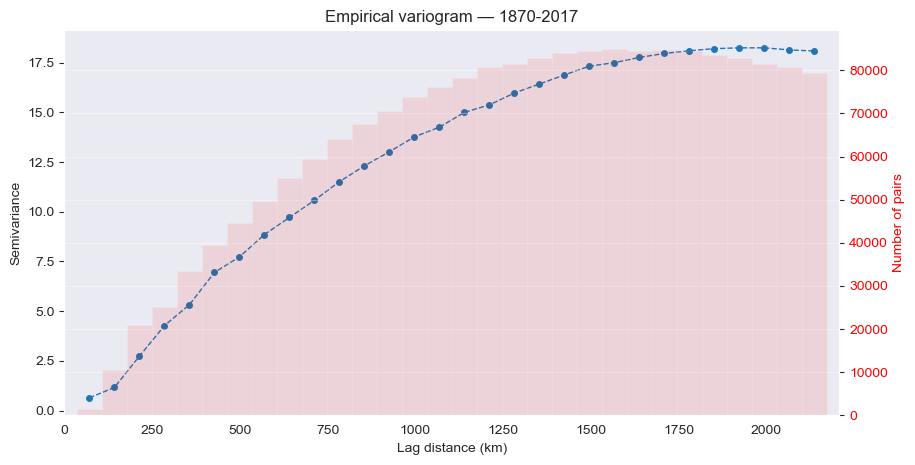

In [6]:
mean_gamma = np.nanmedian(np.vstack(gammas), axis=0)
mean_df = pd.DataFrame({'lag': bins, 'gamma': mean_gamma})
fig, ax = putils.plot_variogram_from_bins_and_gamma(mean_df['lag'],mean_df['gamma'],time='1870-2017',counts = bin_count)
plt.show()